# XAI vs No XAI Comparison - IC50 MPro Task

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for IC50 prediction against SARS-CoV-2 Main Protease (MPro).

**Note**: For IC50, lower values are better. Only molecules with QED ≥ 0.6 are considered valid; molecules below this threshold are assigned a penalty score.


In [108]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random 

random.seed(42)
np.random.seed(42)


In [109]:
# Define paths
RESULTS_DIR = Path("../../data/results/ic50mpro_qed")

# Set to False to hide legend (for combined figures with shared legend)
SHOW_LEGEND = True

# A molecule is valid only if it passes BOTH hard constraints: QED >= QED_THRESHOLD
# AND it is novel (not already in PubChem; see src/molopt_agent/oracles/novel.py,
# which scores 1.0 = novel / 0.0 = not novel). Any molecule failing either constraint
# is disqualified and assigned the pIC50 floor of 0, i.e. IC50 = 1e9 nM
# (9 - log10(1e9) = 0).
INVALID_PENALTY_IC50 = 1_000_000_000
QED_THRESHOLD = 0.6
NOVELTY_THRESHOLD = 0.5

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (No description)", "claude-opus-4.5_no_description"),
    ("REINVENT", "reinvent"),
    ("GraphGA", "graph_ga"),
    ("GP-BO", "gpbo"),
]


## Loading Data


In [110]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def effective_ic50(ic50_score: float, qed: float, novelty: float,
                   qed_threshold: float, novelty_threshold: float, penalty: float) -> float:
    """Effective IC50 [nM] used for scoring, applying the hard-constraint gates.

    A molecule is valid only if it is novel AND drug-like. If it fails *either*
    constraint (Novelty < novelty_threshold, or QED < qed_threshold) it is
    disqualified and assigned the penalty (1e9 nM -> pIC50 0). Otherwise the raw
    IC50 is returned.
    """
    is_valid = (novelty >= novelty_threshold) and (qed >= qed_threshold)
    return ic50_score if is_valid else penalty


def load_results_as_df(results_dir: Path, groups: list, qed_threshold: float,
                       novelty_threshold: float, penalty: float) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.

    The IC50 score is replaced with a penalty for molecules that fail either hard
    constraint (non-novel, or QED below threshold) - see effective_ic50.

    Returns DataFrame with columns: model, replicate, iteration, score, effective_score, qed, novelty, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        
        if not files:
            print(f"Warning: No files in {folder_path} matching ic50mpro_qed_*.json")
            continue
        
        for file_path in files:
            # Extract replicate number from filename (e.g., "rep1", "rep2")
            rep_match = re.search(r'rep(\d+)', file_path.name)
            replicate = int(rep_match.group(1)) if rep_match else 0
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    ic50_score = float(entry["score"])
                    qed = float(entry["scores"]["QED"])
                    novelty = float(entry["scores"].get("Novelty", 1.0))

                    effective_score = effective_ic50(
                        ic50_score, qed, novelty,
                        qed_threshold, novelty_threshold, penalty,
                    )

                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": ic50_score,
                        "effective_score": effective_score,
                        "qed": qed,
                        "novelty": novelty,
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Zero-shot baselines live in a separate directory with a single-batch trace per file.
# They are loaded here (alongside the main runs) so they are available to BOTH the
# AUC table and the progression plots further down.
ZERO_SHOT_DIR = Path("../../data/results/zero_shot/ic50mpro_qed_novel")
ZERO_SHOT_GROUPS = [
    ("Zero-shot (description)", "task"),       # agent receives the task description
    ("Zero-shot (no description)", "generic"),  # generic prompt, no task description
]


def load_zero_shot_df(zs_dir: Path, groups: list, qed_threshold: float,
                      novelty_threshold: float, penalty: float) -> pd.DataFrame:
    """Load zero-shot batch traces, applying the same hard-constraint gates as the XAI runs.

    Each JSON file is treated as one replicate (zero_shot_batch_*.json).
    """
    rows = []
    for display_name, folder_name in groups:
        folder_path = zs_dir / folder_name
        files = sorted(folder_path.glob("zero_shot_batch_*.json"))
        if not files:
            print(f"Warning: No files in {folder_path} matching zero_shot_batch_*.json")
            continue
        for replicate, file_path in enumerate(files, start=1):
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    ic50_score = float(entry["score"])
                    qed = float(entry["scores"]["QED"])
                    novelty = float(entry["scores"].get("Novelty", 1.0))
                    effective_score = effective_ic50(
                        ic50_score, qed, novelty,
                        qed_threshold, novelty_threshold, penalty,
                    )
                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": ic50_score,
                        "effective_score": effective_score,
                        "qed": qed,
                        "novelty": novelty,
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS, QED_THRESHOLD, NOVELTY_THRESHOLD, INVALID_PENALTY_IC50)
df_zs = load_zero_shot_df(
    ZERO_SHOT_DIR, ZERO_SHOT_GROUPS, QED_THRESHOLD, NOVELTY_THRESHOLD, INVALID_PENALTY_IC50,
)


---
## Best-so-far Progression Plot

For IC50 (lower is better), we use cumulative minimum. Molecules with QED < 0.6 are assigned a penalty score.


> **Note on baselines:** With only 50 oracle calls, REINVENT / GraphGA / GP-BO never complete their initialization phase (default population sizes: GraphGA=120, GP-BO=340). These curves therefore represent **random sampling from a drug-like (ZINC) library**, not actual algorithm optimization. Treat them as a random-search lower bound, not as representative of these algorithms' capabilities.

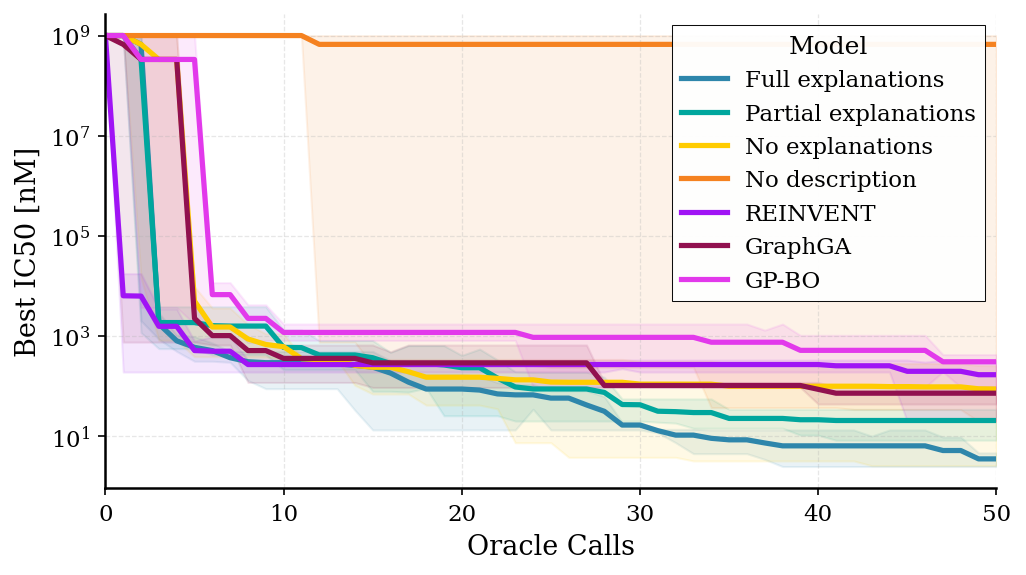

In [111]:
# Compute best-so-far using cummin (for IC50, lower is better)
# Using effective_score which has the penalty applied for QED < threshold / non-novel
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "replicate"])["effective_score"]
    .cummin()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(0, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .fillna(INVALID_PENALTY_IC50)  # Baseline at oracle call 0 = pIC50 floor 0 (no valid molecule yet)
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.6,
    'lines.linewidth': 2.5,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# Define color palette for explanation conditions
model_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No description)': '#f58220',
    'REINVENT': '#A014F5',
    'GraphGA': "#91114F",
    'GP-BO': "#E239EB",
}

# Define legend order and labels
legend_order = [
    'Claude Opus 4.5 (Full XAI)',
    'Claude Opus 4.5 (Partial XAI)',
    'Claude Opus 4.5 (No XAI)',
    'Claude Opus 4.5 (No description)',
    'REINVENT',
    'GraphGA',
    'GP-BO',
]

legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No description)': 'No description',
    'REINVENT': 'REINVENT',
    'GraphGA': 'GraphGA',
    'GP-BO': 'GP-BO',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.5,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=13, fontweight='normal')
ax.set_ylabel("Best IC50 [nM]", fontsize=13, fontweight='normal')
ax.set_xlim(0, 50)
# Use log scale for IC50 as values can span several orders of magnitude
ax.set_yscale('log')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Conditionally show/hide legend
if SHOW_LEGEND:
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [legend_labels.get(label, label) for label in labels]
    legend = ax.legend(
        handles,
        new_labels,
        title='Model',
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=0.95,
        edgecolor='black',
        loc='upper right'
    )
    legend.get_frame().set_linewidth(0.5)
else:
    ax.get_legend().remove()

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/xai_vs_no_xai_ic50mpro_extended.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


---
## AUC Top-1 of pIC50 values over 50 Iterations


In [112]:
# --- AUC Top-1 on pIC50 scale (best-so-far over 50 oracle calls) ---
# pIC50 = -log10(IC50 in M) = 9 - log10(IC50 in nM); HIGHER is better.
# Unlike the nM-AUC above (computed in linear space, dominated by the worst values),
# the AUC of best-so-far pIC50 weights improvements on a log scale automatically and
# needs no arbitrary success threshold. Invalid molecules (non-novel OR QED < threshold)
# use the penalised effective_score of 1e9 nM, i.e. pIC50 = 0.


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


def ic50_nm_to_pic50(ic50_nm):
    """Convert IC50 in nM to pIC50 = -log10(IC50 in M)."""
    return 9.0 - np.log10(ic50_nm)

MAX_ORACLE_CALLS = 50
PIC50_PENALTY = 0

def compute_auc_top1_pic50(group_df, max_oracle_calls=50, penalty_pic50=PIC50_PENALTY):
    """Compute normalized AUC of top-1 (best) pIC50 vs oracle calls for a single run.

    For pIC50, higher is better, so we track the cumulative MAXIMUM. The AUC is the
    area under the best-so-far step curve, normalized by max_oracle_calls, i.e. the
    mean best-so-far pIC50 over the budget. Higher is better.
    """
    sorted_df = group_df.sort_values('iteration')

    best_pic50 = penalty_pic50  # start at floor (worst case) before any valid molecule
    best_at_call = {}

    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        if oracle_call > max_oracle_calls:
            break
        pic50 = ic50_nm_to_pic50(float(row['effective_score']))
        if pic50 > best_pic50:
            best_pic50 = pic50
        best_at_call[oracle_call] = best_pic50

    if not best_at_call:
        return penalty_pic50  

    # Left Riemann sum over the step function, extended to max_oracle_calls.
    auc = 0.0
    prev_call = 0
    prev_best = penalty_pic50
    for call in sorted(best_at_call.keys()):
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    auc += prev_best * (max_oracle_calls - prev_call)

    # Normalize -> mean best-so-far pIC50 over the budget
    return auc / max_oracle_calls


# Compute AUC Top-1 (pIC50) for each model/replicate, including the zero-shot baselines
df_auc = pd.concat([df, df_zs], ignore_index=True)
auc_pic50_records = []
for (model, replicate), group in df_auc.groupby(['model', 'replicate']):
    auc_pic50_records.append({
        'model': model,
        'replicate': replicate,
        'auc_top1_pic50': compute_auc_top1_pic50(group, MAX_ORACLE_CALLS),
    })

auc_pic50_df = pd.DataFrame(auc_pic50_records)

# Summarize by model with bootstrap CI
auc_pic50_summary_rows = []
for model, group in auc_pic50_df.groupby('model'):
    values = group['auc_top1_pic50']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    auc_pic50_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1 (pIC50)": mean_val,
        "CI 95% -": mean_val - ci_low,
        "CI 95% +": ci_high - mean_val,
        "N": len(values),
    })

auc_pic50_summary = (
    pd.DataFrame(auc_pic50_summary_rows)
    .set_index("Model")
    .sort_values("Mean AUC Top-1 (pIC50)", ascending=False)
    .round(2)
)

print(f"AUC Top-1 (pIC50) over {MAX_ORACLE_CALLS} oracle calls — HIGHER is better")
print(f"pIC50 = 9 - log10(IC50 [nM]); QED < {QED_THRESHOLD} or non-novel -> pIC50 = 0")
print()
auc_pic50_summary

AUC Top-1 (pIC50) over 50 oracle calls — HIGHER is better
pIC50 = 9 - log10(IC50 [nM]); QED < 0.6 or non-novel -> pIC50 = 0



/Users/fabian/miniconda3/envs/polaris/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/fabian/miniconda3/envs/polaris/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,Mean AUC Top-1 (pIC50),CI 95% -,CI 95% +,N
Model,,,,
Claude Opus 4.5 (Full XAI),7.07,0.15,0.08,3
Claude Opus 4.5 (Partial XAI),6.74,0.46,0.27,3
Claude Opus 4.5 (No XAI),6.66,0.83,0.47,3
REINVENT,6.43,0.15,0.26,3
GraphGA,6.40,0.48,0.28,3
GP-BO,5.71,0.13,0.07,3
Zero-shot (description),5.22,0.37,0.60,3
Claude Opus 4.5 (No description),1.76,1.76,3.51,3
Zero-shot (no description),0.00,NaN,NaN,3


---
## Best-so-far Progression: Zero-shot vs. Algorithmic Baselines

Best-so-far plots, both sharing the four Claude explanation conditions (full / partial / no explanation / no description):

1. **Algorithmic baselines** — REINVENT, GraphGA, GP-BO.
2. **Zero-shot baselines** — `zero-shot (description)` (= `task` subfolder, the agent gets the task description) and `zero-shot (no description)` (= `generic` subfolder), each generating all candidates in a single batch without iterative oracle feedback.

The zero-shot traces are loaded from `data/results/zero_shot/ic50mpro_qed_novel/{task,generic}` and use the same QED penalty as the XAI runs.

Each comparison is rendered on **two scales**: raw **IC50 [nM]** (log axis, lower is better) and **pIC50** = `9 - log10(IC50 [nM])` (linear axis, higher is better) — the same pIC50 convention as the AUC Top-1 table above. The compact zero-shot figures are saved legend-less for side-by-side placement under the shared horizontal legend.


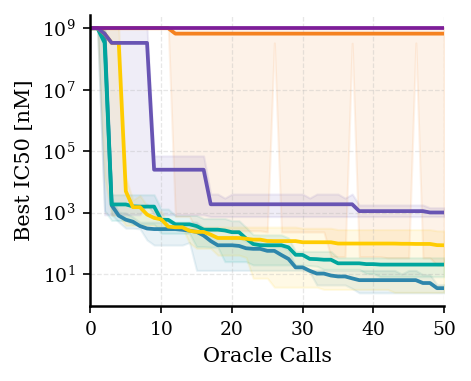

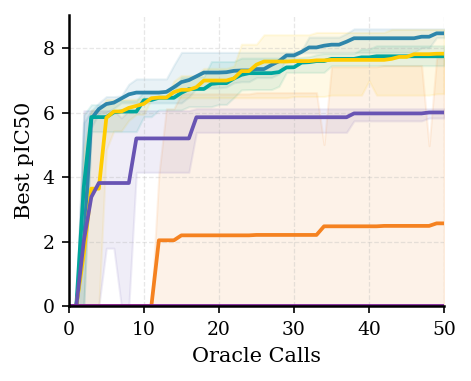

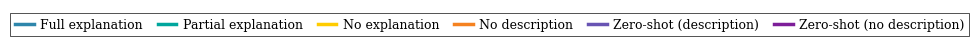

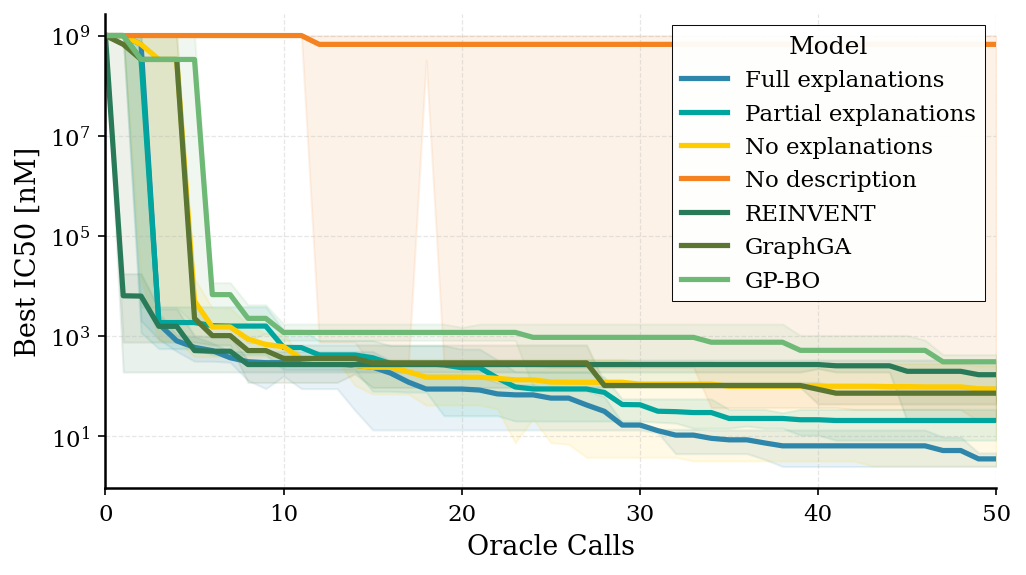

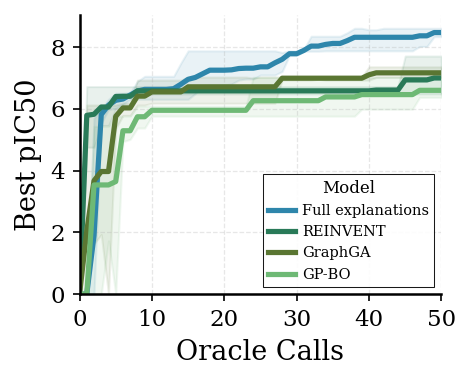

In [113]:
# Zero-shot vs. baseline progression figures.
# The zero-shot data (df_zs) is loaded in the "Loading Data" section above.
from matplotlib.lines import Line2D

# The four Claude explanation conditions shared by both plots
XAI_MODELS = [
    "Claude Opus 4.5 (Full XAI)",
    "Claude Opus 4.5 (Partial XAI)",
    "Claude Opus 4.5 (No XAI)",
    "Claude Opus 4.5 (No description)",
]

# Combined frame: original runs (XAI + algorithmic baselines) + zero-shot runs
df_combined = pd.concat([df, df_zs], ignore_index=True)

# Colors and legend labels for every model that may appear in either plot
zs_plot_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No description)': '#f58220',
    'REINVENT': '#297a58',
    'GraphGA': "#5a7632",
    'GP-BO': "#6eb975",
    'Zero-shot (description)': '#6854B3',
    'Zero-shot (no description)': "#7D1E99",
}
zs_legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No description)': 'No description',
    'REINVENT': 'REINVENT',
    'GraphGA': 'GraphGA',
    'GP-BO': 'GP-BO',
    'Zero-shot (description)': 'Zero-shot (description)',
    'Zero-shot (no description)': 'Zero-shot (no description)',
}


def _best_so_far_long(source_df, model_order):
    """Best-so-far IC50 [nM] (running cummin of effective_score) in long form for plotting."""
    sub = source_df[source_df["model"].isin(model_order)].copy()
    sub["best_so_far"] = (
        sub.sort_values("iteration")
        .groupby(["model", "replicate"])["effective_score"]
        .cummin()
    )
    max_iter = 50
    all_iterations = range(0, max_iter + 1)
    return (
        sub[sub["iteration"] <= max_iter]
        .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
        .reindex(all_iterations)
        .ffill()
        .fillna(INVALID_PENALTY_IC50)  # Baseline at oracle call 0 = pIC50 floor 0 (no valid molecule yet)
        .melt(ignore_index=False)
        .reset_index()
    )


def _style_and_save(ax, fig, save_path, model_order, *, show_legend, label_fontsize,
                    tick_fontsize, ylabel, yscale, legend_loc, appendix=False):
    ax.set_xlabel("Oracle Calls", fontsize=label_fontsize, fontweight='normal')
    ax.set_ylabel(ylabel, fontsize=label_fontsize, fontweight='normal')
    ax.set_xlim(0, 50)
    if yscale:
        ax.set_yscale(yscale)
    ax.tick_params(labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        if not appendix:
            handles, labels = ax.get_legend_handles_labels()
            new_labels = [zs_legend_labels.get(label, label) for label in labels]
            legend = ax.legend(
                handles, new_labels, title='Model', frameon=True,
                fancybox=False, shadow=False, framealpha=0.95,
                edgecolor='black', loc=legend_loc,
            )
            legend.get_frame().set_linewidth(0.5)
        else:
            handles, labels = ax.get_legend_handles_labels()
            new_labels = [zs_legend_labels.get(label, label) for label in labels]
            legend = ax.legend(
            handles, new_labels, title='Model', frameon=True,
            fancybox=False, shadow=False, framealpha=0.9,
            edgecolor='black', loc='lower right', fontsize=7,
            title_fontsize=8, handlelength=1.8, handletextpad=0.5,
            borderpad=0.35
        )
        legend.get_frame().set_linewidth(0.5)
    elif ax.get_legend() is not None:
        ax.get_legend().remove()

    plt.tight_layout()
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()


def plot_best_so_far_ic50(source_df, model_order, save_path, *,
                          show_legend=True, figsize=(7, 4),
                          label_fontsize=13, tick_fontsize=11, linewidth=2.5):
    """Best-so-far IC50 [nM] progression (log axis, lower is better)."""
    dfp = _best_so_far_long(source_df, model_order)
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sns.lineplot(
        data=dfp, x="iteration", y="value", hue="model", hue_order=model_order,
        palette={m: zs_plot_colors[m] for m in model_order},
        errorbar=('ci', 95), err_kws={'alpha': 0.1}, linewidth=linewidth, ax=ax,
    )
    _style_and_save(ax, fig, save_path, model_order, show_legend=show_legend,
                    label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,
                    ylabel="Best IC50 [nM]", yscale='log', legend_loc='upper right')


def plot_best_so_far_pic50(source_df, model_order, save_path, *,
                           show_legend=True, figsize=(7, 4), appendix=False,
                           label_fontsize=13, tick_fontsize=11, linewidth=2.5):
    """Best-so-far pIC50 progression (linear axis, higher is better).

    pIC50 = 9 - log10(IC50 [nM]); same convention as the AUC Top-1 table above.
    The running-minimum IC50 maps to the running-maximum pIC50; invalid molecules
    (non-novel or QED < threshold) map to pIC50 = 0.
    """
    dfp = _best_so_far_long(source_df, model_order)
    dfp["value"] = 9.0 - np.log10(dfp["value"])  # nM -> pIC50
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sns.lineplot(
        data=dfp, x="iteration", y="value", hue="model", hue_order=model_order,
        palette={m: zs_plot_colors[m] for m in model_order},
        errorbar=('ci', 95), err_kws={'alpha': 0.1}, linewidth=linewidth, ax=ax,
    )
    ax.set_ylim(bottom=0)
    _style_and_save(ax, fig, save_path, model_order, show_legend=show_legend,
                    label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,
                    ylabel="Best pIC50", yscale=None, legend_loc='lower right', appendix=appendix)


def generate_shared_legend(save_path, linewidth=2.5):
    """Standalone horizontal legend (one row) shared by the two zero-shot subfigures."""
    legend_entries = [
        ("Full explanation", zs_plot_colors['Claude Opus 4.5 (Full XAI)']),
        ("Partial explanation", zs_plot_colors['Claude Opus 4.5 (Partial XAI)']),
        ("No explanation", zs_plot_colors['Claude Opus 4.5 (No XAI)']),
        ("No description", zs_plot_colors['Claude Opus 4.5 (No description)']),
        ("Zero-shot (description)", zs_plot_colors['Zero-shot (description)']),
        ("Zero-shot (no description)", zs_plot_colors['Zero-shot (no description)']),
    ]
    handles = [Line2D([0], [0], color=color, lw=linewidth, label=label)
               for label, color in legend_entries]

    fig, ax = plt.subplots(figsize=(6.5, 0.4))
    ax.set_axis_off()
    legend = ax.legend(
        handles=handles, loc='center', ncol=len(legend_entries),
        frameon=True, fancybox=False, shadow=False, framealpha=0.95,
        edgecolor='black', handlelength=1.5, handletextpad=0.5,
        columnspacing=1.2, fontsize=9,
    )
    legend.get_frame().set_linewidth(0.5)
    fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.05)
    plt.show()


# Single-column paper: the two zero-shot subfigures sit side by side (~0.49\linewidth each),
# so they are saved compact and legend-less; the shared legend goes on top in LaTeX.
COMPACT_KWARGS = dict(show_legend=False, figsize=(3.3, 2.7),
                      label_fontsize=10, tick_fontsize=9, linewidth=1.8)

ZS_MODELS = XAI_MODELS + ['Zero-shot (description)', 'Zero-shot (no description)']
BASE_MODELS = XAI_MODELS + ['REINVENT', 'GraphGA', 'GP-BO']

# --- Zero-shot baselines (legend-less, publication-sized) ---
plot_best_so_far_ic50(
    df_combined, ZS_MODELS,
    './figures/xai_vs_no_xai_ic50mpro_extended_zeroshot.pdf', **COMPACT_KWARGS,
)
plot_best_so_far_pic50(
    df_combined, ZS_MODELS,
    './figures/xai_vs_no_xai_ic50mpro_extended_pic50_zeroshot.pdf', **COMPACT_KWARGS,
)

# Shared horizontal legend (4 explanation conditions + 2 zero-shot baselines)
generate_shared_legend('./figures/xai_vs_no_xai_zeroshot_legend.pdf')

# --- Algorithmic baselines (kept with legend; for the appendix) ---
plot_best_so_far_ic50(
    df_combined, BASE_MODELS,
    './figures/xai_vs_no_xai_ic50mpro_extended_baselines.pdf',
)
plot_best_so_far_pic50(
    df_combined, ['Claude Opus 4.5 (Full XAI)', 'REINVENT', 'GraphGA', 'GP-BO'],
    './figures/xai_vs_no_xai_ic50mpro_extended_pic50_baselines.pdf',
    figsize=(3.3, 2.7), appendix = True 
)
